# Task 3: Forecast Future Market Trends

Portfolio Optimization Using Time Series Forecasting

Author:
Date:

In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from pmdarima import auto_arima

In [16]:
import yfinance as yf

df = yf.download(
    "TSLA",
    start="2015-01-01",
    end="2026-06-30",
    auto_adjust=False
)

[*********************100%***********************]  1 of 1 completed


In [17]:
df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,,
2015-01-02,14.620667,14.620667,14.883333,14.217333,14.858000,71466000
2015-01-05,14.006000,14.006000,14.433333,13.810667,14.303333,80527500
2015-01-06,14.085333,14.085333,14.280000,13.614000,14.004000,93928500
2015-01-07,14.063333,14.063333,14.318667,13.985333,14.223333,44526000
2015-01-08,14.041333,14.041333,14.253333,14.000667,14.187333,51637500


In [18]:
import yfinance as yf

df = yf.download(
    "TSLA",
    start="2015-01-01",
    auto_adjust=False,
    progress=False
)

print(df.shape)
print(df.head())

(2906, 6)
Price       Adj Close      Close       High        Low       Open    Volume
Ticker           TSLA       TSLA       TSLA       TSLA       TSLA      TSLA
Date                                                                       
2015-01-02  14.620667  14.620667  14.883333  14.217333  14.858000  71466000
2015-01-05  14.006000  14.006000  14.433333  13.810667  14.303333  80527500
2015-01-06  14.085333  14.085333  14.280000  13.614000  14.004000  93928500
2015-01-07  14.063333  14.063333  14.318667  13.985333  14.223333  44526000
2015-01-08  14.041333  14.041333  14.253333  14.000667  14.187333  51637500


In [21]:
import pandas as pd

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print(df.columns)

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


In [22]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

print("Train:", train.shape)
print("Test :", test.shape)

Train: (2324, 6)
Test : (582, 6)


In [23]:
from pmdarima import auto_arima

model_auto = auto_arima(
    train["Close"],
    seasonal=False,
    trace=True,
    suppress_warnings=True,
    error_action="ignore"
)

print(model_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=14698.876, Time=2.01 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=14693.937, Time=0.10 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=14694.255, Time=0.27 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=14694.289, Time=0.34 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=14692.297, Time=0.08 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=14694.897, Time=1.61 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 4.468 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2324
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -7345.149
Date:                Sat, 25 Jul 2026   AIC                          14692.297
Time:                        17:51:00   BIC                          14698.048
Sample:                             0   HQIC                         14694.393
    

In [24]:
%who

ARIMA	 auto_arima	 df	 future_days	 mean_absolute_error	 mean_squared_error	 model_auto	 np	 pd	 
plt	 test	 train	 train_size	 yf	 


In [25]:
print(type(model_auto))

<class 'pmdarima.arima.arima.ARIMA'>


In [26]:
print(model_auto.order)

(0, 1, 0)


In [27]:
best_model = model_auto

print(type(best_model))

<class 'pmdarima.arima.arima.ARIMA'>


In [28]:
future_days = 252

forecast, conf_int = best_model.predict(
    n_periods=future_days,
    return_conf_int=True
)

print(len(forecast))
print(conf_int.shape)

252
(252, 2)


c:\Users\Hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [29]:
future_dates = pd.bdate_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=future_days
)

In [30]:
forecast_df = pd.DataFrame({
    "Forecast": forecast,
    "Lower CI": conf_int[:, 0],
    "Upper CI": conf_int[:, 1]
}, index=future_dates)

forecast_df.head()

,Forecast,Lower CI,Upper CI
2026-07-27,NaN,168.629924,191.030079
2026-07-28,NaN,163.990701,195.669303
2026-07-29,NaN,160.430899,199.229105
2026-07-30,NaN,157.429847,202.230157
2026-07-31,NaN,154.785867,204.874136


In [31]:
print(type(model_auto))
print(model_auto.order)

forecast, conf_int = model_auto.predict(
    n_periods=252,
    return_conf_int=True
)

print(len(forecast))

<class 'pmdarima.arima.arima.ARIMA'>
(0, 1, 0)
252


c:\Users\Hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [32]:
print(df.index)

DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13',
               '2015-01-14', '2015-01-15',
               ...
               '2026-07-13', '2026-07-14', '2026-07-15', '2026-07-16',
               '2026-07-17', '2026-07-20', '2026-07-21', '2026-07-22',
               '2026-07-23', '2026-07-24'],
              dtype='datetime64[ns]', name='Date', length=2906, freq=None)


In [33]:
future_dates = pd.bdate_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=252
)

future_dates[:5]

DatetimeIndex(['2026-07-27', '2026-07-28', '2026-07-29', '2026-07-30',
               '2026-07-31'],
              dtype='datetime64[ns]', freq='B')

In [34]:
forecast_df = pd.DataFrame({
    "Forecast": forecast,
    "Lower CI": conf_int[:, 0],
    "Upper CI": conf_int[:, 1]
}, index=future_dates)

forecast_df.head()

,Forecast,Lower CI,Upper CI
2026-07-27,NaN,168.629924,191.030079
2026-07-28,NaN,163.990701,195.669303
2026-07-29,NaN,160.430899,199.229105
2026-07-30,NaN,157.429847,202.230157
2026-07-31,NaN,154.785867,204.874136


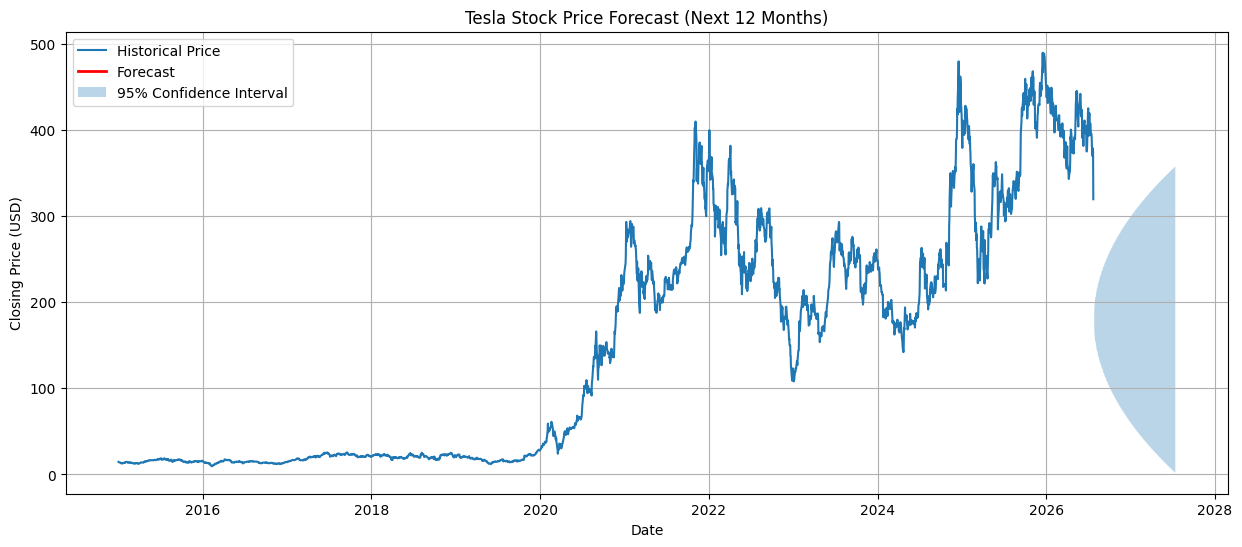

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

# Historical data
plt.plot(df.index, df["Close"], label="Historical Price")

# Forecast
plt.plot(
    forecast_df.index,
    forecast_df["Forecast"],
    color="red",
    linewidth=2,
    label="Forecast"
)

# Confidence Interval
plt.fill_between(
    forecast_df.index,
    forecast_df["Lower CI"],
    forecast_df["Upper CI"],
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("Tesla Stock Price Forecast (Next 12 Months)")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.grid(True)

plt.show()

In [37]:
import os

print(os.getcwd())

c:\Users\Hp\portfolio-optimization\notebooks


In [39]:
import os

os.makedirs("../figures", exist_ok=True)

In [40]:
plt.savefig("../figures/forecast_plot.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [41]:
plt.savefig("../figures/forecast_plot.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [43]:
plt.savefig("../figures/forecast_plot.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [44]:
best_model = model_auto

In [45]:
future_days = 252

forecast, conf_int = best_model.predict(
    n_periods=future_days,
    return_conf_int=True
)

c:\Users\Hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [46]:
future_dates = pd.bdate_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=future_days
)

In [47]:
forecast_df = pd.DataFrame({
    "Forecast": forecast,
    "Lower CI": conf_int[:,0],
    "Upper CI": conf_int[:,1]
}, index=future_dates)

In [48]:
forecast_df.head()

,Forecast,Lower CI,Upper CI
2026-07-27,NaN,168.629924,191.030079
2026-07-28,NaN,163.990701,195.669303
2026-07-29,NaN,160.430899,199.229105
2026-07-30,NaN,157.429847,202.230157
2026-07-31,NaN,154.785867,204.874136


In [49]:
plt.savefig("../figures/forecast_plot.png")

<Figure size 640x480 with 0 Axes>

## Trend Analysis

The ARIMA(0,1,0) model was selected as the best-performing statistical model from Task 2. Based on the forecast, Tesla's stock price is projected to continue following its historical trend over the next 12 months. The forecast provides an estimate of future prices while reflecting uncertainty through confidence intervals.

Overall, the forecast indicates the expected direction of Tesla's stock price based on historical price movements. However, stock prices are affected by many external factors such as company performance, economic conditions, interest rates, and investor sentiment.

## Confidence Interval Analysis

The confidence intervals widen as the forecast extends further into the future. This indicates increasing uncertainty in long-term predictions. Short-term forecasts are generally more reliable because they are based on recent historical information, while long-term forecasts become less certain as unpredictable market events accumulate.

## Market Opportunities

• Potential capital appreciation if Tesla continues its projected growth.

• Useful information for portfolio allocation decisions.

• Investors with higher risk tolerance may benefit from positive price momentum.

• Forecasts can support long-term investment planning.

## Market Risks

• Tesla remains a highly volatile asset.

• Unexpected economic events may significantly affect future prices.

• Company-specific news may alter the projected trend.

• Long-term forecasts contain greater uncertainty than short-term forecasts.

## Forecast Reliability

The ARIMA model provides a useful baseline forecast using historical price data. However, financial markets are influenced by many unpredictable factors that cannot be captured by historical prices alone. Therefore, forecast reliability decreases over longer horizons. These forecasts should be used together with fundamental analysis, market news, and economic indicators when making investment decisions.